# MACE / ab-initio trajectory matching

Compare active-state MACE potential energies and forces, plus all NAC tensors, with ab-initio reference values at identical geometries. Enable only the metrics available for the trajectories being analysed. The analysis deliberately stops when the paired trajectories do not share the same geometry.


## 1. Read data

In [10]:
from pathlib import Path
import json
import re

import matplotlib.pyplot as plt
import numpy as np

# Paths are relative to the repository root.
mace_trajs_folder = Path("ethene_02_dynamic_first_from_equi/traj-allmols/Singlet_1")
ab_initio_trajs_folder = Path("A01_FromEqui")


def trajectory_id(path: Path) -> int:
    match = re.fullmatch(r"TRAJ_(\d+)", path.name)
    if match is None:
        raise ValueError(f"Not a trajectory directory: {path}")
    return int(match.group(1))


def discover_trajectories(folder: Path) -> dict[int, Path]:
    if not folder.is_dir():
        raise FileNotFoundError(f"Trajectory folder does not exist: {folder}")
    trajectories = {trajectory_id(path): path for path in folder.glob("TRAJ_*") if path.is_dir()}
    if not trajectories:
        raise ValueError(f"No TRAJ_* subfolders found in {folder}")
    return dict(sorted(trajectories.items()))


mace_traj_by_id = discover_trajectories(mace_trajs_folder)
ab_initio_traj_by_id = discover_trajectories(ab_initio_trajs_folder)

# Public lists requested for the two trajectory roots, in numeric TRAJ_* order.
mace_trajs = list(mace_traj_by_id.values())
ab_initio_trajs = list(ab_initio_traj_by_id.values())

common_traj_ids = sorted(mace_traj_by_id.keys() & ab_initio_traj_by_id.keys())
missing_mace_ids = sorted(ab_initio_traj_by_id.keys() - mace_traj_by_id.keys())
missing_ab_initio_ids = sorted(mace_traj_by_id.keys() - ab_initio_traj_by_id.keys())
if missing_mace_ids or missing_ab_initio_ids:
    raise ValueError(
        f"Unpaired trajectories; missing MACE: {missing_mace_ids}, "
        f"missing ab-initio: {missing_ab_initio_ids}"
    )

print(f"Found {len(mace_trajs)} MACE and {len(ab_initio_trajs)} ab-initio trajectories.")


Found 100 MACE and 100 ab-initio trajectories.


## 2. Functions

In [11]:
from functools import lru_cache

HARTREE_TO_EV = 27.211386245988
BOHR_TO_ANGSTROM = 0.529177210903
HARTREE_PER_BOHR_TO_EV_PER_ANGSTROM = HARTREE_TO_EV / BOHR_TO_ANGSTROM
min_energy_threshold = 0.05  # eV; smaller per-timestep errors do not contribute cumulatively
max_energy_threshold = 0.5  # eV; upper cumulative-energy-error limit for a matched trajectory
min_force_threshold = 0.05  # eV/Å; smaller per-timestep force RMSEs do not contribute cumulatively
max_force_threshold = 0.5  # eV/Å; upper cumulative-force-error limit for a matched trajectory
min_nac_threshold = 0.005  # Å^-1; smaller per-timestep NAC RMSEs do not contribute cumulatively
max_nac_threshold = 0.05  # Å^-1; upper cumulative-NAC-error limit for a matched trajectory

# Toggle which cumulative metrics determine a match and are plotted in section 3.
use_energy = True
use_forces = True
use_nacs = False  # Current output.dat files contain SHARC's -123 NAC placeholder.


def require_file(path: Path) -> Path:
    if not path.is_file() or path.stat().st_size == 0:
        raise FileNotFoundError(f"Missing or empty file: {path}")
    return path


def parse_xyz_frames(
    path: Path, *, require_ref_energy: bool = False, require_ref_forces: bool = False,
    require_ref_nacs: bool = False,
):
    """Read XYZ/extXYZ frames and optional REF_energy, REF_forces, and REF_nacs metadata."""
    lines = require_file(path).read_text(encoding="utf-8").splitlines()
    frames, cursor = [], 0
    while cursor < len(lines):
        if not lines[cursor].strip():
            cursor += 1
            continue
        try:
            natoms = int(lines[cursor].strip())
        except ValueError as error:
            raise ValueError(f"{path}: expected atom count at line {cursor + 1}") from error
        if natoms <= 0 or cursor + natoms + 1 >= len(lines):
            raise ValueError(f"{path}: incomplete XYZ frame at line {cursor + 1}")
        comment = lines[cursor + 1]
        atom_lines = lines[cursor + 2: cursor + 2 + natoms]
        frame_index = len(frames)
        symbols, coordinates, coordinate_error = [], [], None
        for line in atom_lines:
            fields = line.split()
            if len(fields) < 4:
                coordinate_error = f"malformed atom line: {line!r}"
                break
            symbols.append(fields[0])
            try:
                coordinate = [float(value) for value in fields[1:4]]
            except ValueError:
                coordinate_error = f"non-numeric coordinates in {line!r}"
                break
            if not np.all(np.isfinite(coordinate)):
                coordinate_error = f"non-finite coordinates in {line!r}"
                break
            coordinates.append(coordinate)
        time_match = re.search(r"\bt=\s*([-+0-9.eE]+)", comment)
        metadata = {}
        for key, required in (
            ("REF_energy", require_ref_energy),
            ("REF_forces", require_ref_forces),
            ("REF_nacs", require_ref_nacs),
        ):
            match = re.search(rf"{key}=\"_JSON (.*?)\"", comment)
            if required and match is None:
                raise ValueError(f"{path}: {key} missing from frame {frame_index}")
            if match is not None:
                try:
                    value = np.asarray(json.loads(match.group(1)), dtype=float)
                except (json.JSONDecodeError, TypeError, ValueError) as error:
                    raise ValueError(f"{path}: invalid {key} in frame {frame_index}") from error
                if not np.all(np.isfinite(value)):
                    raise ValueError(f"{path}: non-finite {key} in frame {frame_index}")
                metadata[key] = (
                    value.squeeze() if key == "REF_energy"
                    else value[0] if value.ndim >= 1 and value.shape[0] == 1 else value
                )
        if coordinate_error is not None:
            print(f"Warning: {path}: invalid coordinates at frame {frame_index} ({coordinate_error}); stopping this trajectory before that frame.")
            break
        frames.append({
            "symbols": tuple(symbols),
            "coordinates": np.asarray(coordinates, dtype=float),
            "time_fs": None if time_match is None else float(time_match.group(1)),
            "ref_energy_ev": metadata.get("REF_energy"),
            "ref_forces": metadata.get("REF_forces"),
            "ref_nacs": metadata.get("REF_nacs"),
        })
        cursor += natoms + 2
    if not frames:
        raise ValueError(f"{path}: no XYZ frames found")
    return frames


def ab_initio_xyz_path(ab_initio_traj: Path) -> Path:
    candidates = sorted(ab_initio_traj.glob("*_CASSCF.xyz"))
    if len(candidates) != 1:
        raise FileNotFoundError(f"{ab_initio_traj}: expected exactly one *_CASSCF.xyz file")
    return candidates[0]


def parse_mace_lis(path: Path):
    """Read step, time, active MCH state, and active potential energy from output.lis."""
    rows = []
    for line in require_file(path).read_text(encoding="utf-8").splitlines():
        fields = line.split()
        if not fields or fields[0].startswith("#"):
            continue
        if len(fields) < 7:
            continue
        try:
            rows.append((int(fields[0]), float(fields[1]), int(fields[3]), float(fields[5])))
        except ValueError:
            continue
    if not rows:
        raise ValueError(f"{path}: no valid output.lis data rows")
    return np.asarray(rows, dtype=float)


def read_ezero_ev(mace_traj: Path) -> float:
    input_path = require_file(mace_traj / "input")
    match = re.search(r"^\s*ezero\s+([-+0-9.eE]+)", input_path.read_text(encoding="utf-8"), re.MULTILINE)
    if match is None:
        raise ValueError(f"{input_path}: ezero not found")
    return float(match.group(1)) * HARTREE_TO_EV


def _parse_output_dat_vector(lines: list[str], start: int, path: Path, label: str, natoms: int) -> np.ndarray:
    try:
        vector = np.asarray([[float(value) for value in lines[start + offset].split()] for offset in range(natoms)], dtype=float)
    except (IndexError, ValueError) as error:
        raise ValueError(f"{path}: malformed {label} block") from error
    if vector.shape != (natoms, 3) or not np.all(np.isfinite(vector)):
        raise ValueError(f"{path}: invalid {label} block")
    return vector


def parse_mace_output_dat(path: Path, natoms: int):
    """Read MCH gradients and NACdr vectors from SHARC output.dat in native atomic units."""
    lines = require_file(path).read_text(encoding="utf-8").splitlines()
    frames, current = [], None
    gradient_pattern = re.compile(r"! 15 Gradients \(MCH\) State\s+(\d+)")
    nac_pattern = re.compile(r"! 16 NACdr matrix element \(MCH\)\s+(\d+)\s+(\d+)")
    for index, line in enumerate(lines):
        if line == "! 0 Step":
            if current is not None:
                frames.append(current)
            current = {"gradients": {}, "nacs": {}}
            continue
        if current is None:
            continue
        gradient_match = gradient_pattern.fullmatch(line)
        if gradient_match is not None:
            current["gradients"][int(gradient_match.group(1))] = _parse_output_dat_vector(
                lines, index + 1, path, "gradient", natoms
            )
            continue
        nac_match = nac_pattern.fullmatch(line)
        if nac_match is not None:
            state_pair = (int(nac_match.group(1)), int(nac_match.group(2)))
            current["nacs"][state_pair] = _parse_output_dat_vector(
                lines, index + 1, path, "NACdr", natoms
            )
    if current is not None:
        frames.append(current)
    if not frames:
        raise ValueError(f"{path}: no SHARC output.dat frames found")
    return frames


@lru_cache(maxsize=None)
def paired_trajectory_data(mace_traj: Path, ab_initio_traj: Path):
    """Return time-aligned MACE frames, CASSCF frames, and active MCH states."""
    mace_frames = parse_xyz_frames(mace_traj / "output.xyz")
    ab_frames = parse_xyz_frames(
        ab_initio_xyz_path(ab_initio_traj), require_ref_energy=True, require_ref_forces=True,
        require_ref_nacs=True,
    )
    lis = parse_mace_lis(mace_traj / "output.lis")
    mace_output = parse_mace_output_dat(mace_traj / "output.dat", len(mace_frames[0]["symbols"]))
    common_frame_count = min(len(lis), len(mace_frames), len(ab_frames), len(mace_output))
    if len(lis) != len(mace_frames):
        print(
            f"Warning: {mace_traj.name}: output.lis has {len(lis)} rows but output.xyz has "
            f"{len(mace_frames)} frames; using the first {common_frame_count} paired frame(s)."
        )
    if common_frame_count == 0:
        return np.asarray([], dtype=float), (), (), (), np.asarray([], dtype=int)
    lis = lis[:common_frame_count]
    mace_frames = mace_frames[:common_frame_count]
    ab_frames = ab_frames[:common_frame_count]
    mace_output = mace_output[:common_frame_count]
    times = lis[:, 1]
    xyz_times = np.asarray([frame["time_fs"] for frame in mace_frames], dtype=float)
    if np.any(np.isnan(xyz_times)) or not np.allclose(times, xyz_times, rtol=0, atol=1e-8):
        raise ValueError(f"{mace_traj.name}: output.xyz and output.lis times do not match")
    active_states = lis[:, 2].astype(int)
    reference_energies = np.asarray([frame["ref_energy_ev"] for frame in ab_frames], dtype=float)
    if reference_energies.ndim != 2:
        raise ValueError(f"{ab_initio_traj.name}: REF_energy must contain one energy per electronic state")
    if np.any(active_states < 1) or np.any(active_states > reference_energies.shape[1]):
        raise ValueError(f"{mace_traj.name}: active MCH state is outside REF_energy bounds")
    return times, tuple(mace_frames), tuple(ab_frames), tuple(mace_output), active_states


def _tensor_rmse(error: np.ndarray) -> float:
    return float(np.sqrt(np.mean(np.square(error))))


def _normalise_state_tensor(value: np.ndarray, natoms: int, path: Path, frame_index: int, name: str) -> np.ndarray:
    """Normalise extXYZ tensors stored as either (states, atoms, xyz) or (atoms, states, xyz)."""
    if value.ndim != 3 or value.shape[-1] != 3:
        raise ValueError(f"{path}: {name} in frame {frame_index} must be a three-dimensional Cartesian tensor")
    if value.shape[1] == natoms:
        return value
    if value.shape[0] == natoms:
        return np.swapaxes(value, 0, 1)
    raise ValueError(f"{path}: {name} in frame {frame_index} must contain {natoms} atoms")


def _validate_nac_tensor(value: np.ndarray, natoms: int, path: Path, frame_index: int) -> np.ndarray:
    value = _normalise_state_tensor(value, natoms, path, frame_index, "REF_nacs")
    if value.shape[0] == 0:
        raise ValueError(f"{path}: REF_nacs in frame {frame_index} must contain at least one state pair")
    return value


def per_timestep_energy_error(mace_traj: Path, ab_initio_traj: Path) -> tuple[np.ndarray, np.ndarray]:
    """Return MACE times (fs) and absolute active-state potential-energy errors (eV)."""
    times, _, ab_frames, _, active_states = paired_trajectory_data(mace_traj, ab_initio_traj)
    reference_energies = np.asarray([frame["ref_energy_ev"] for frame in ab_frames], dtype=float)
    lis = parse_mace_lis(mace_traj / "output.lis")[:len(times)]
    ab_active_potential = reference_energies[np.arange(len(times)), active_states - 1] - read_ezero_ev(mace_traj)
    return times, np.abs(lis[:, 3] - ab_active_potential)


def per_timestep_force_error(mace_traj: Path, ab_initio_traj: Path) -> tuple[np.ndarray, np.ndarray]:
    """Return active-state force-tensor RMSEs (eV/Å) at each paired frame."""
    times, mace_frames, ab_frames, mace_output, active_states = paired_trajectory_data(mace_traj, ab_initio_traj)
    errors = []
    ab_xyz = ab_initio_xyz_path(ab_initio_traj)
    for frame_index, (mace_frame, ab_frame, output_frame, active_state) in enumerate(zip(mace_frames, ab_frames, mace_output, active_states)):
        ab_forces = ab_frame["ref_forces"]
        mace_forces = np.asarray([
            -output_frame["gradients"][state] * HARTREE_PER_BOHR_TO_EV_PER_ANGSTROM
            for state in sorted(output_frame["gradients"])
        ])
        natoms = len(mace_frame["symbols"])
        mace_forces = _normalise_state_tensor(mace_forces, natoms, mace_traj / "output.dat", frame_index, "gradients")
        ab_forces = _normalise_state_tensor(ab_forces, natoms, ab_xyz, frame_index, "REF_forces")
        if mace_forces.shape != ab_forces.shape:
            raise ValueError(f"{mace_traj.name}: MACE and CASSCF REF_forces shapes differ in frame {frame_index}")
        if active_state > mace_forces.shape[0]:
            raise ValueError(f"{mace_traj.name}: active MCH state is outside REF_forces bounds")
        errors.append(_tensor_rmse(mace_forces[active_state - 1] - ab_forces[active_state - 1]))
    return times, np.asarray(errors, dtype=float)


def per_timestep_nac_error(mace_traj: Path, ab_initio_traj: Path) -> tuple[np.ndarray, np.ndarray]:
    """Return sign-invariant all-state-pair NAC-tensor RMSEs (Å^-1)."""
    times, mace_frames, ab_frames, mace_output, _ = paired_trajectory_data(mace_traj, ab_initio_traj)
    errors = []
    ab_xyz = ab_initio_xyz_path(ab_initio_traj)
    for frame_index, (mace_frame, ab_frame, output_frame) in enumerate(zip(mace_frames, ab_frames, mace_output)):
        ab_nacs = ab_frame["ref_nacs"]
        mace_nacs = np.asarray([
            output_frame["nacs"][state_pair] / BOHR_TO_ANGSTROM
            for state_pair in sorted(pair for pair in output_frame["nacs"] if pair[0] < pair[1])
        ])
        if mace_nacs.size and np.all(np.isclose(np.abs(mace_nacs), 123.0 / BOHR_TO_ANGSTROM)):
            raise ValueError(
                f"{mace_traj.name}: output.dat frame {frame_index} contains SHARC's -123 NAC placeholder, "
                "so MACE NAC predictions are unavailable"
            )
        natoms = len(mace_frame["symbols"])
        mace_nacs = _validate_nac_tensor(mace_nacs, natoms, mace_traj / "output.dat", frame_index)
        ab_nacs = _validate_nac_tensor(ab_nacs, natoms, ab_xyz, frame_index)
        if mace_nacs.shape != ab_nacs.shape:
            raise ValueError(f"{mace_traj.name}: MACE and CASSCF REF_nacs shapes differ in frame {frame_index}")
        pair_errors = [
            min(_tensor_rmse(mace_pair - ab_pair), _tensor_rmse(mace_pair + ab_pair))
            for mace_pair, ab_pair in zip(mace_nacs, ab_nacs)
        ]
        errors.append(float(np.sqrt(np.mean(np.square(pair_errors)))))
    return times, np.asarray(errors, dtype=float)


def cumulative_energy_error(
    mace_traj: Path, ab_initio_traj: Path, threshold: float = min_energy_threshold
) -> tuple[np.ndarray, np.ndarray]:
    """Return time and cumulative error, excluding per-timestep errors below ``threshold`` eV."""
    if threshold < 0:
        raise ValueError("threshold must be non-negative")
    times, errors = per_timestep_energy_error(mace_traj, ab_initio_traj)
    included_errors = np.where(errors >= threshold, errors, 0.0)
    return times, np.cumsum(included_errors)


def _cumulative_error(
    error_function, mace_traj: Path, ab_initio_traj: Path, threshold: float
) -> tuple[np.ndarray, np.ndarray]:
    if threshold < 0:
        raise ValueError("threshold must be non-negative")
    times, errors = error_function(mace_traj, ab_initio_traj)
    return times, np.cumsum(np.where(errors >= threshold, errors, 0.0))


def cumulative_force_error(
    mace_traj: Path, ab_initio_traj: Path, threshold: float = min_force_threshold
) -> tuple[np.ndarray, np.ndarray]:
    """Return cumulative active-state force RMSE, excluding errors below ``threshold`` eV/Å."""
    return _cumulative_error(per_timestep_force_error, mace_traj, ab_initio_traj, threshold)


def cumulative_nac_error(
    mace_traj: Path, ab_initio_traj: Path, threshold: float = min_nac_threshold
) -> tuple[np.ndarray, np.ndarray]:
    """Return cumulative sign-invariant NAC RMSE, excluding errors below ``threshold`` Å^-1."""
    return _cumulative_error(per_timestep_nac_error, mace_traj, ab_initio_traj, threshold)


def max_match_duration(
    mace_traj: Path, ab_initio_traj: Path, *, energy_threshold: float = max_energy_threshold,
    force_threshold: float = max_force_threshold, nac_threshold: float = max_nac_threshold,
) -> float:
    """Return duration while every enabled cumulative metric remains within its maximum."""
    metric_definitions = (
        (use_energy, "energy", cumulative_energy_error, energy_threshold),
        (use_forces, "force", cumulative_force_error, force_threshold),
        (use_nacs, "NAC", cumulative_nac_error, nac_threshold),
    )
    enabled_metrics = [definition for definition in metric_definitions if definition[0]]
    if not enabled_metrics:
        raise ValueError("Enable at least one of use_energy, use_forces, or use_nacs")

    times, matching = None, None
    for _, metric_name, cumulative_error_function, maximum_threshold in enabled_metrics:
        if maximum_threshold < 0:
            raise ValueError(f"{metric_name} maximum threshold must be non-negative")
        metric_times, cumulative_error = cumulative_error_function(mace_traj, ab_initio_traj)
        if times is None:
            times = metric_times
            matching = cumulative_error <= maximum_threshold
        else:
            if not np.array_equal(times, metric_times):
                raise ValueError(f"{mace_traj.name}: enabled cumulative-metric times do not match")
            matching &= cumulative_error <= maximum_threshold

    matching_indices = np.flatnonzero(matching)
    if matching_indices.size == 0:
        return 0.0
    return float(times[matching_indices[-1]] - times[0])


## 3. Plots

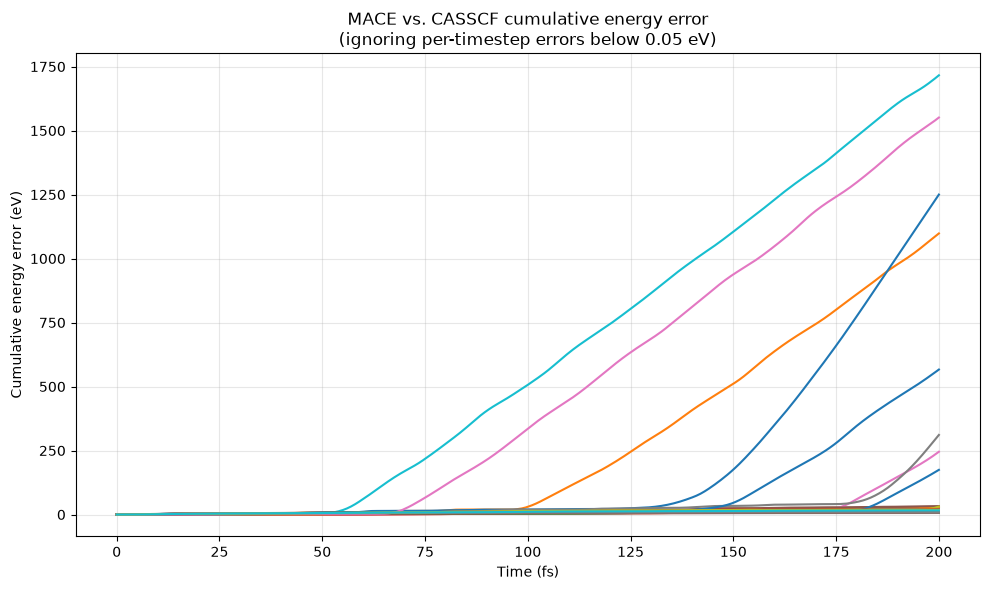

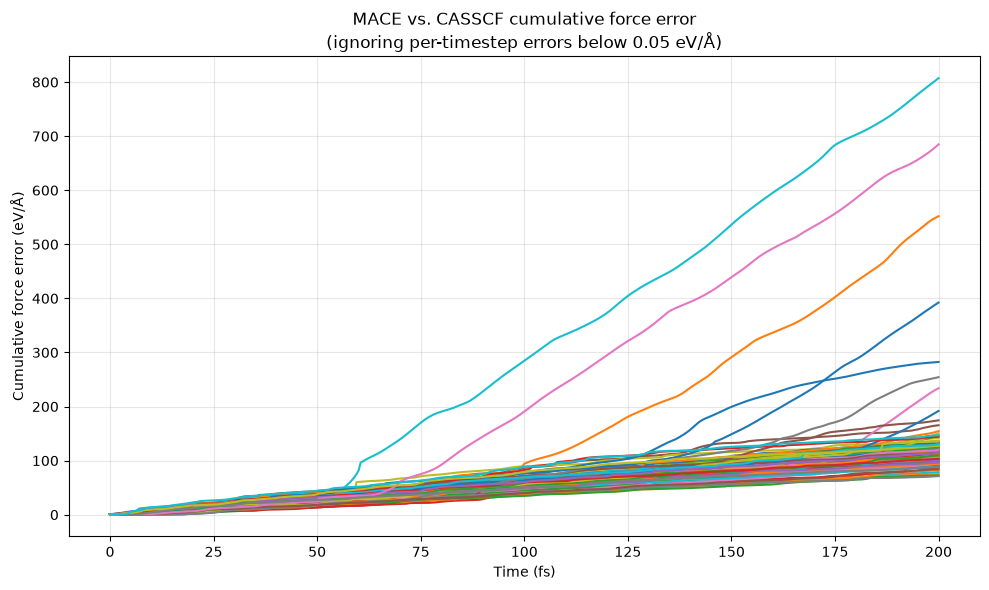

In [12]:
trajectory_ids_to_plot = range(1, 101)

# Build every requested pair. Geometry diagnostics are printed during the calculation.
requested_pairs = []
for traj_id in trajectory_ids_to_plot:
    if traj_id not in mace_traj_by_id or traj_id not in ab_initio_traj_by_id:
        raise KeyError(f"TRAJ_{traj_id:05d} is missing from one of the input folders")
    mace_traj = mace_traj_by_id[traj_id]
    ab_initio_traj = ab_initio_traj_by_id[traj_id]
    requested_pairs.append((traj_id, mace_traj, ab_initio_traj))

plot_definitions = tuple(
    definition for definition in (
        (use_energy, "energy", cumulative_energy_error, min_energy_threshold, "eV"),
        (use_forces, "force", cumulative_force_error, min_force_threshold, "eV/Å"),
        (use_nacs, "NAC", cumulative_nac_error, min_nac_threshold, "Å^-1"),
    ) if definition[0]
)
if not plot_definitions:
    raise ValueError("Enable at least one of use_energy, use_forces, or use_nacs")

for _, metric_name, cumulative_error_function, minimum_threshold, units in plot_definitions:
    fig, ax = plt.subplots(figsize=(10, 6))
    for traj_id, mace_traj, ab_initio_traj in requested_pairs:
        time_fs, cumulative_error = cumulative_error_function(mace_traj, ab_initio_traj)
        ax.plot(time_fs, cumulative_error, label=f"TRAJ_{traj_id:05d}")

    ax.set_xlabel("Time (fs)")
    ax.set_ylabel(f"Cumulative {metric_name} error ({units})")
    ax.set_title(
        f"MACE vs. CASSCF cumulative {metric_name} error\n"
        f"(ignoring per-timestep errors below {minimum_threshold:g} {units})"
    )
    ax.grid(alpha=0.3)
    fig.tight_layout()
    plt.show()


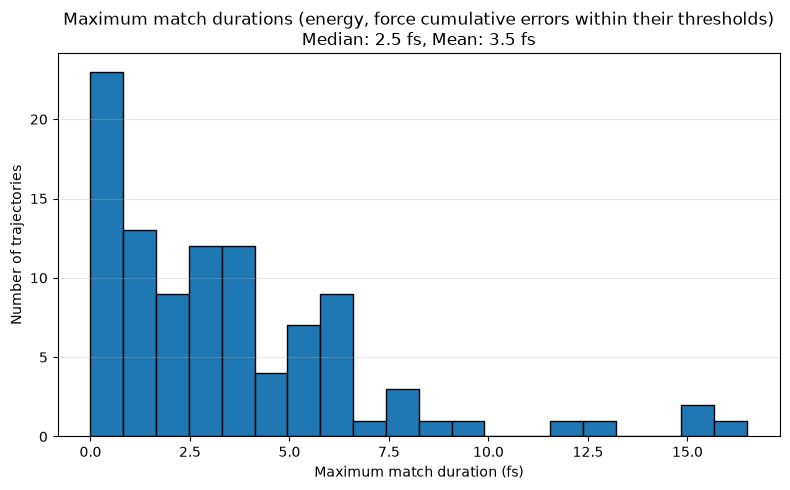

In [13]:

enabled_metric_names = ", ".join(metric_name for _, metric_name, *_ in plot_definitions)

match_durations_fs = np.asarray([
    max_match_duration(mace_traj, ab_initio_traj)
    for _, mace_traj, ab_initio_traj in requested_pairs
])

fig_hist, ax_hist = plt.subplots(figsize=(8, 5))
ax_hist.hist(match_durations_fs, bins=20, edgecolor="black")
ax_hist.set_xlabel("Maximum match duration (fs)")
ax_hist.set_ylabel("Number of trajectories")
ax_hist.set_title(
    f"Maximum match durations ({enabled_metric_names} cumulative errors within their thresholds)\n"
    f"Median: {np.median(match_durations_fs):.1f} fs, Mean: {np.mean(match_durations_fs):.1f} fs"
)
ax_hist.grid(axis="y", alpha=0.3)
fig_hist.tight_layout()
plt.show()


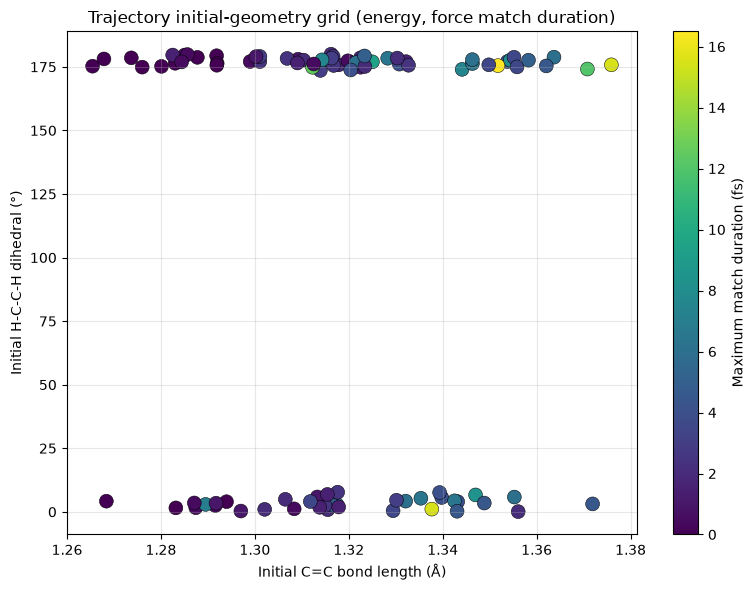

In [14]:
# Initial-geometry map: each square is one trajectory, coloured by maximum match duration.
def initial_cc_hcch(mace_traj: Path) -> tuple[float, float]:
    """Return the initial C=C distance (Å) and absolute H-C-C-H torsion (degrees)."""
    initial_frame = parse_xyz_frames(mace_traj / "output.xyz")[0]
    symbols = initial_frame["symbols"]
    coordinates = initial_frame["coordinates"]
    carbons = [index for index, symbol in enumerate(symbols) if symbol == "C"]
    hydrogens = [index for index, symbol in enumerate(symbols) if symbol == "H"]
    if len(carbons) < 2 or len(hydrogens) < 2:
        raise ValueError("initial frame needs at least two C atoms and two H atoms")
    carbon_a, carbon_b = min(
        ((i, j) for i in carbons for j in carbons if i < j),
        key=lambda pair: np.linalg.norm(coordinates[pair[0]] - coordinates[pair[1]]),
    )
    hydrogen_a = min(hydrogens, key=lambda index: np.linalg.norm(coordinates[index] - coordinates[carbon_a]))
    hydrogen_b = min(hydrogens, key=lambda index: np.linalg.norm(coordinates[index] - coordinates[carbon_b]))
    p0, p1, p2, p3 = coordinates[[hydrogen_a, carbon_a, carbon_b, hydrogen_b]]
    b0, b1, b2 = -(p1 - p0), p2 - p1, p3 - p2
    b1 /= np.linalg.norm(b1)
    v, w = b0 - np.dot(b0, b1) * b1, b2 - np.dot(b2, b1) * b1
    if np.linalg.norm(v) == 0 or np.linalg.norm(w) == 0:
        raise ValueError("initial H-C-C-H torsion is undefined")
    torsion = np.degrees(np.arctan2(np.dot(np.cross(b1, v), w), np.dot(v, w)))
    return float(np.linalg.norm(p1 - p2)), float(abs((torsion + 180) % 360 - 180))


initial_geometry_records = []
for (trajectory_id, mace_traj, _), duration_fs in zip(requested_pairs, match_durations_fs):
    try:
        cc_bond_angstrom, hcch_dihedral_deg = initial_cc_hcch(mace_traj)
    except ValueError as error:
        print(f"Warning: TRAJ_{trajectory_id:05d}: omitted from initial-geometry grid ({error}).")
        continue
    initial_geometry_records.append((trajectory_id, cc_bond_angstrom, hcch_dihedral_deg, duration_fs))

initial_geometry = np.asarray(initial_geometry_records, dtype=float)
if initial_geometry.size == 0:
    raise ValueError("No trajectories have a plottable initial C=C / H-C-C-H geometry")

fig_grid, ax_grid = plt.subplots(figsize=(8, 6))
points = ax_grid.scatter(
    initial_geometry[:, 1], initial_geometry[:, 2], c=initial_geometry[:, 3],
    cmap="viridis", s=100, edgecolors="black", linewidths=0.35,
)
colorbar = fig_grid.colorbar(points, ax=ax_grid)
colorbar.set_label("Maximum match duration (fs)")
ax_grid.set_xlabel("Initial C=C bond length (Å)")
ax_grid.set_ylabel("Initial H-C-C-H dihedral (°)")
ax_grid.set_title(f"Trajectory initial-geometry grid ({enabled_metric_names} match duration)")
ax_grid.grid(alpha=0.3)
fig_grid.tight_layout()
plt.show()
